In [2]:
import keras.backend as K
import os
import numpy as np
import pylab as plt
from keras.utils import to_categorical
from keras.models import Model
from keras.layers import Input
from keras.layers import LSTM
from keras.layers import Dense
from keras.layers.convolutional import Conv3D
from keras.layers.convolutional_recurrent import ConvLSTM2D
from keras.layers.normalization import BatchNormalization
from keras.models import load_model
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
from sklearn.preprocessing import minmax_scale
from keras.utils import to_categorical
from keras.regularizers import l2
from keras.backend import clip 
import math

In [39]:
"""
3-layer stacked ConvLSTM2D Encoder-Decoder
"""

def define_models_3_precipitation(n_filter, filter_size):
    # define training encoder
    encoder_inputs = Input(shape=(None, 128, 110, 1))
    encoder_1 = ConvLSTM2D(filters = n_filter, kernel_size=filter_size, activation='relu', padding='same', return_sequences=True, return_state=True,
                           kernel_regularizer=l2(0.001), recurrent_regularizer=l2(0.001), bias_regularizer=l2(0.001))
    encoder_2 = ConvLSTM2D(filters = 32, kernel_size=filter_size, activation='relu', padding='same', return_sequences=True, return_state=True,
                           kernel_regularizer=l2(0.001), recurrent_regularizer=l2(0.001), bias_regularizer=l2(0.001))
    encoder_3 = ConvLSTM2D(filters = 32, kernel_size=filter_size, activation='relu', padding='same', return_sequences=True, return_state=True,
                           kernel_regularizer=l2(0.001), recurrent_regularizer=l2(0.001), bias_regularizer=l2(0.001))
    encoder_outputs_1, encoder_state_h_1, encoder_state_c_1 = encoder_1(encoder_inputs)
    encoder_outputs_2, encoder_state_h_2, encoder_state_c_2 = encoder_2(encoder_outputs_1)
    encoder_outputs_3, encoder_state_h_3, encoder_state_c_3 = encoder_3(encoder_outputs_2)
    # define training decoder
    decoder_inputs = Input(shape=(None, 128, 110, 1))
    decoder_1 = ConvLSTM2D(filters=n_filter, kernel_size=filter_size, activation='relu', padding='same', return_sequences=True, return_state=True,
                           kernel_regularizer=l2(0.001), recurrent_regularizer=l2(0.001), bias_regularizer=l2(0.001))
    decoder_2 = ConvLSTM2D(filters=32, kernel_size=filter_size, activation='relu', padding='same', return_sequences=True, return_state=True,
                           kernel_regularizer=l2(0.001), recurrent_regularizer=l2(0.001), bias_regularizer=l2(0.001))
    decoder_3 = ConvLSTM2D(filters=32, kernel_size=filter_size, activation='relu', padding='same', return_sequences=True, return_state=True,
                           kernel_regularizer=l2(0.001), recurrent_regularizer=l2(0.001), bias_regularizer=l2(0.001))
    decoder_outputs_1, _, _ = decoder_1([decoder_inputs, encoder_state_h_1, encoder_state_c_1])
    decoder_outputs_2, _, _ = decoder_2([decoder_outputs_1, encoder_state_h_2, encoder_state_c_2])
    decoder_outputs_3, _, _ = decoder_3([decoder_outputs_2, encoder_state_h_3, encoder_state_c_3])
    decoder_conv3d = Conv3D(filters=1, kernel_size=(1,1,32), activation='relu', padding='same', data_format='channels_last',
                            kernel_regularizer=l2(0.001), bias_regularizer=l2(0.001))
    decoder_outputs = decoder_conv3d(decoder_outputs_3)
    
    model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
    #print(model.summary(line_length=250))
    # define inference encoder
    encoder_model = Model(encoder_inputs, 
                          [encoder_state_h_1, encoder_state_c_1, encoder_state_h_2, encoder_state_c_2, encoder_state_h_3, encoder_state_c_3])
    
    # define inference decoder
    decoder_state_input_h_1 = Input(shape=(128, 110,n_filter))
    decoder_state_input_c_1 = Input(shape=(128, 110,n_filter))
    decoder_state_input_h_2 = Input(shape=(128, 110,32))
    decoder_state_input_c_2 = Input(shape=(128, 110,32))
    decoder_state_input_h_3 = Input(shape=(128, 110,32))
    decoder_state_input_c_3 = Input(shape=(128, 110,32))
    decoder_output_1, decoder_state_h_1_new, decoder_state_c_1_new = decoder_1([decoder_inputs, decoder_state_input_h_1, decoder_state_input_c_1])
    decoder_output_2, decoder_state_h_2_new, decoder_state_c_2_new = decoder_2([decoder_output_1, decoder_state_input_h_2, decoder_state_input_c_2])
    decoder_output_3, decoder_state_h_3_new, decoder_state_c_3_new = decoder_3([decoder_output_2, decoder_state_input_h_3, decoder_state_input_c_3])
    decoder_output = decoder_conv3d(decoder_output_3)
    decoder_model = Model([decoder_inputs , decoder_state_input_h_1 , decoder_state_input_c_1, decoder_state_input_h_2 , decoder_state_input_c_2, 
                           decoder_state_input_h_3 , decoder_state_input_c_3],
                          [decoder_output, decoder_state_h_1_new, decoder_state_c_1_new, decoder_state_h_2_new, decoder_state_c_2_new, 
                           decoder_state_h_3_new, decoder_state_c_3_new])
    
    return model, encoder_model, decoder_model


In [45]:
train_3_precipitation, infenc_3_precipitation, infdec_3_precipitation = define_models_3_precipitation(n_filter=32, filter_size=3)
train_3_precipitation.compile(loss='mse', optimizer='adam', metrics=['mae'])
train_3_precipitation.load_weights('saved-3LayerconvLSTM-420.h5')


In [46]:
def predict_sequence_3(infenc, infdec, source, n_steps):
    # encode
    state_h_1, state_c_1, state_h_2, state_c_2, state_h_3, state_c_3 = infenc.predict(source)  # source_dim = ()
    #decoder_input = source[:,-1,:,:,:].reshape((1,1,64,64,1))
    decoder_input = np.repeat(0,128*110).reshape((1,1,128,110,1))
    # collect predictions
    output = list()
    for t in range(n_steps):
        # predict next char
        yhat, h_1, c_1, h_2, c_2, h_3, c_3 = infdec.predict([decoder_input, state_h_1, state_c_1, state_h_2, state_c_2, state_h_3, state_c_3])
        # store prediction
        output.append(yhat[0,0,:])
        # update state
        state_h_1, state_c_1, state_h_2, state_c_2, state_h_3, state_c_3 = h_1, c_1, h_2, c_2, h_3, c_3
        # update target sequence
        decoder_input = yhat
    return np.array(output)


In [47]:
data = np.load('data_with_frame_splits.npy')

In [48]:
which = 1

#which =  np.random.randint(5485)
track = data[which,:16,:,:,:]
track.shape
history = track[np.newaxis, ::, ::, ::, ::]
history.shape

prediction_3 = predict_sequence_3(infenc_3_precipitation, infdec_3_precipitation, history, 5)
print(prediction_3.shape)

(5, 128, 110, 1)


In [49]:
from sklearn.preprocessing import minmax_scale
shape = prediction_3.shape
temp = minmax_scale(prediction_3.ravel(), feature_range=(0,255)).reshape(shape)
temp.shape

(5, 128, 110, 1)

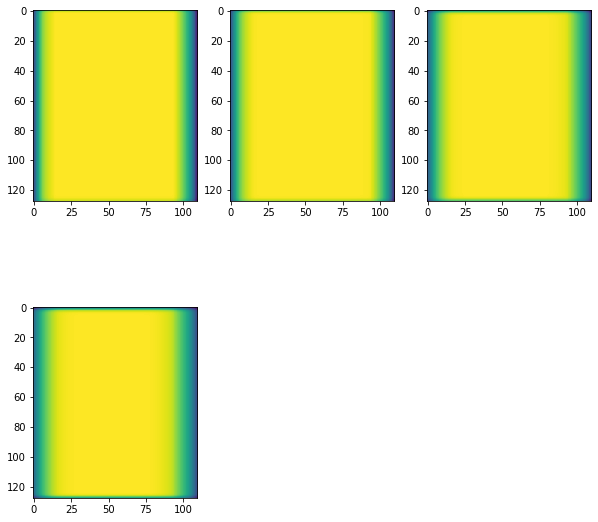

In [50]:
plt.figure(1,figsize=(10,10))
for i in range(4):
    plt.subplot(2,3,i+1)
    plt.imshow(temp[i, ::, ::, 0])

#     plt.subplot(212)
#     plt.imshow(track[i, ::, ::, 0])
plt.show()

###### 